# Phase 1: Environment Setup & Data Ingestion

In [ ]:
# Install the core spatial libraries
!pip install osmnx geopandas rasterio scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.5 MB/s eta 0:00:00


Reaching out to OpenStreetMap servers for Bengaluru, Karnataka, India...
Success! Total schools found: 1412


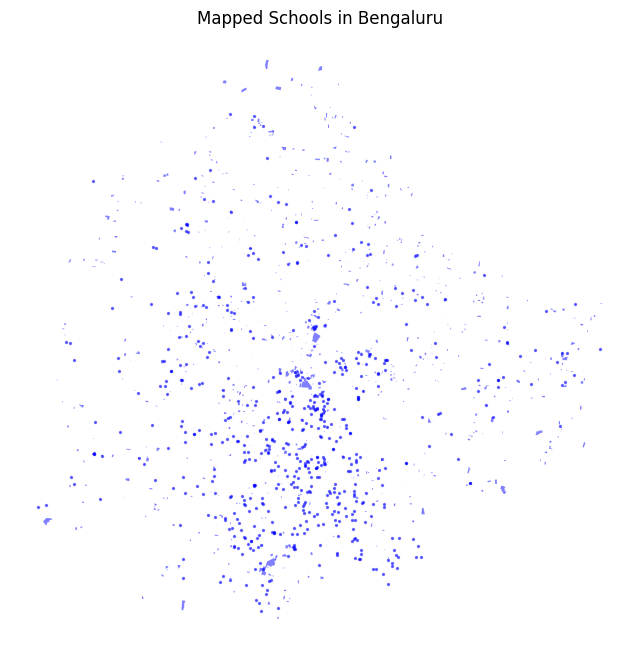

In [ ]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt

# Define our target city
place_name = "Bengaluru, Karnataka, India"

# Define what we are looking for (Schools)
tags = {'amenity': 'school'}
print(f"Reaching out to OpenStreetMap servers for {place_name}...")

# Fetch the data
schools = ox.features_from_place(place_name, tags)

# Clean the data to keep only the names and GPS geometry
schools_clean = schools[['name', 'geometry']].dropna(subset=['geometry'])

print(f"Success! Total schools found: {len(schools_clean)}")

# Let's visualize it to make sure it worked
schools_clean.plot(markersize=2, color='blue', figsize=(8, 8), alpha=0.5)
plt.title("Mapped Schools in Bengaluru")
plt.axis('off')
plt.show()

In [ ]:
import osmnx as ox
import time

# Let's track how long this takes
start_time = time.time()

# 1. Define the network type (we only care about walking paths, not highways)
network_type = 'walk'

print(f"Downloading the walkable street network for {place_name}...")
print("Grab a coffee, this might take 5 to 10 minutes for a city this big!")

# 2. Fetch the graph
# (custom_filter avoids pulling in private indoor corridors to save memory)
G = ox.graph_from_place(place_name, network_type=network_type,
                        custom_filter='["highway"]["area"!~"yes"]["access"!~"private"]')

# 3. Save the graph so we don't have to do this again tomorrow
filepath = "bengaluru_walk.graphml"
ox.save_graphml(G, filepath)

end_time = time.time()
print(f"Success! Network downloaded and saved as {filepath}.")
print(f"Total Nodes (Intersections): {len(G.nodes)}")
print(f"Total Edges (Streets): {len(G.edges)}")
print(f"Time taken: {round((end_time - start_time) / 60, 2)} minutes.")

Grab a coffee, this might take 5 to 10 minutes for a city this big!
Success! Network downloaded and saved as bengaluru_walk.graphml.
Total Nodes (Intersections): 184909
Total Edges (Streets): 495640
Time taken: 3.8 minutes.


In [ ]:
from google.colab import drive
import os
import shutil

# 1. Mount Google Drive (Connects Colab to your personal Drive)
drive.mount('/content/drive')

# 2. Create a dedicated folder for our project
project_dir = '/content/drive/MyDrive/Spatial_Apartheid_Project/Data'
os.makedirs(project_dir, exist_ok=True)

# 3. Copy the heavy road network file to your Drive
shutil.copy("bengaluru_walk.graphml", f"{project_dir}/bengaluru_walk.graphml")

# 4. Save the schools data as a GeoJSON file to your Drive
schools_clean.to_file(f"{project_dir}/bengaluru_schools.geojson", driver='GeoJSON')

print(f"Success! Your data is permanently saved in your Google Drive at: {project_dir}")

Mounted at /content/drive
Success! Your data is permanently saved in your Google Drive at: /content/drive/MyDrive/Spatial_Apartheid_Project/Data


Loading vector data...
Loaded 1412 schools.
Loaded 509 slum polygons.


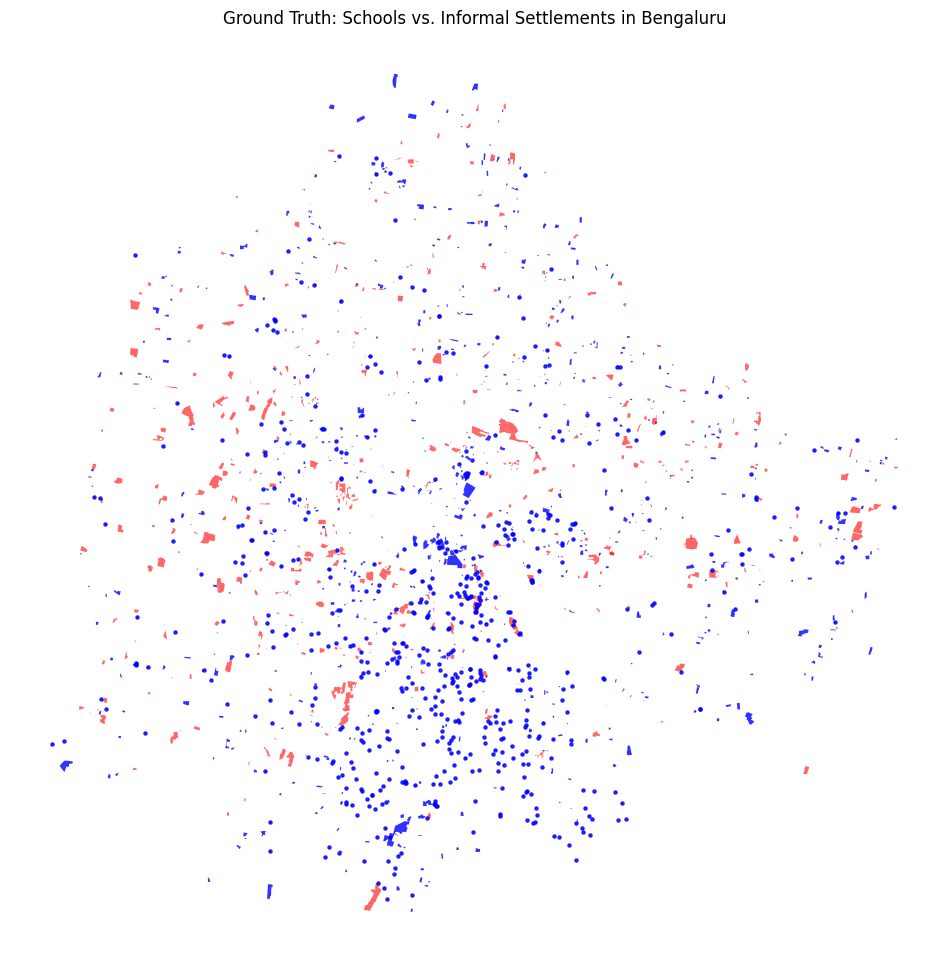

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# 1. Define the paths to the files in your Google Drive
project_dir = '/content/drive/MyDrive/Spatial_Apartheid_Project/Data'
schools_path = f"{project_dir}/bengaluru_schools.geojson"
slums_path = f"{project_dir}/blr_slums.json" # Adjust the filename if you saved it differently

# 2. Load the datasets using GeoPandas
print("Loading vector data...")
schools_gdf = gpd.read_file(schools_path)
slums_gdf = gpd.read_file(slums_path)

# 3. Ensure they use the exact same coordinate system (EPSG:4326 is standard GPS lat/long)
schools_gdf = schools_gdf.to_crs(epsg=4326)
slums_gdf = slums_gdf.to_crs(epsg=4326)

print(f"Loaded {len(schools_gdf)} schools.")
print(f"Loaded {len(slums_gdf)} slum polygons.")

# 4. Plot them together to verify they overlap correctly!
fig, ax = plt.subplots(figsize=(12, 12))

# Plot slums in RED
slums_gdf.plot(ax=ax, color='red', alpha=0.6, label='Informal Settlements')

# Plot schools in BLUE
schools_gdf.plot(ax=ax, markersize=5, color='blue', alpha=0.8, label='Schools')

plt.title("Ground Truth: Schools vs. Informal Settlements in Bengaluru")
plt.axis('off')
plt.show()

Fetching detailed school data...
Strict primary filtering left too few schools. Defaulting to all Government Schools.
Filtered down to 257 Government Schools.


/tmp/ipykernel_25535/3767399433.py:38: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


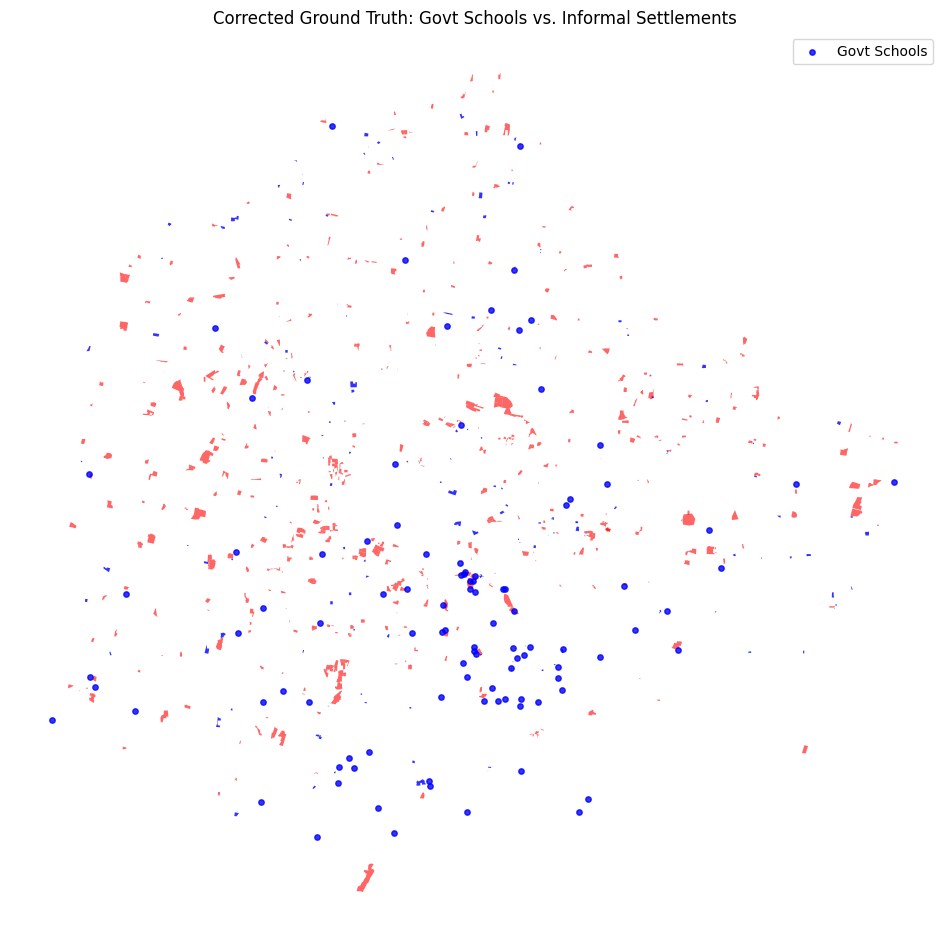

In [ ]:
# 1. We need to fetch the raw data again, but this time ask for ALL the metadata
print("Fetching detailed school data...")
detailed_schools = ox.features_from_place(place_name, tags={'amenity': 'school'})

# 2. Filter for 'Public' or 'Government' schools (OSM uses 'operator:type' or 'ownership')
# It's also a good idea to check the name for words like 'Govt', 'Government', 'BBMP'
gov_schools = detailed_schools[
    (detailed_schools['operator:type'].str.contains('public|government', case=False, na=False)) |
    (detailed_schools['name'].str.contains('Govt|Government|BBMP|Public', case=False, na=False))
]

# 3. Filter for Primary Schools (OSM uses 'isces:level' or 'school:level')
# In India, primary is usually level 1
primary_gov_schools = gov_schools[
    (gov_schools['isced:level'].str.contains('1', case=False, na=False)) |
    (gov_schools['name'].str.contains('Primary|Lower', case=False, na=False))
]

# If the strict filtering removes too much (OSM tags in India can be messy),
# let's fall back to just Government Schools for the analysis to be safe.
if len(primary_gov_schools) < 50:
    print("Strict primary filtering left too few schools. Defaulting to all Government Schools.")
    final_schools = gov_schools[['name', 'geometry']].dropna(subset=['geometry'])
else:
    final_schools = primary_gov_schools[['name', 'geometry']].dropna(subset=['geometry'])

print(f"Filtered down to {len(final_schools)} Government Schools.")

# 4. Save the corrected data!
final_schools.to_file(f"{project_dir}/bengaluru_schools_corrected.geojson", driver='GeoJSON')

# 5. Plot the corrected map
fig, ax = plt.subplots(figsize=(12, 12))
slums_gdf.plot(ax=ax, color='red', alpha=0.6, label='Informal Settlements')
final_schools.plot(ax=ax, markersize=15, color='blue', alpha=0.8, label='Govt Schools')
plt.title("Corrected Ground Truth: Govt Schools vs. Informal Settlements")
plt.axis('off')
plt.legend()
plt.show()

# Phase 2: AI-Powered Satellite Classification (Sentinel-2)

In [ ]:
import ee

ee.Authenticate()

# Replace with your actual project ID
my_project_id = 'spatial-apartheid-blr'

try:
    ee.Initialize(project=my_project_id)
    print("Earth Engine Initialized Successfully!")
except Exception as e:
    print(f"Initialization failed: {e}")

Earth Engine Initialized Successfully!


In [ ]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.9 MB/s eta 0:00:00


In [ ]:
import ee
import geemap

# Initialize the interactive map centered on Bengaluru
Map = geemap.Map(center=[12.9716, 77.5946], zoom=11)

# 1. Define Bengaluru Region of Interest (ROI)
# Using a central point and a 15km buffer to cover the main city
bengaluru_point = ee.Geometry.Point([77.5946, 12.9716])
roi = bengaluru_point.buffer(15000)

print("Querying Sentinel-2 satellites for cloud-free Bengaluru imagery...")

# 2. Fetch Sentinel-2 Surface Reflectance Data
# We use Jan-Feb 2024 to guarantee clear skies (no monsoon clouds)
dataset = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(roi)
           .filterDate('2024-01-01', '2024-03-01')
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 5))
           .median() # Takes the median pixel to remove transient shadows
           .clip(roi))

# 3. Feature Engineering: Calculate NDVI (Vegetation Index)
# Formula: (NIR - RED) / (NIR + RED) -> (Band 8 - Band 4)
ndvi = dataset.normalizedDifference(['B8', 'B4']).rename('NDVI')

# 4. Feature Engineering: Calculate NDBI (Built-Up/Concrete Index)
# Formula: (SWIR1 - NIR) / (SWIR1 + NIR) -> (Band 11 - Band 8)
ndbi = dataset.normalizedDifference(['B11', 'B8']).rename('NDBI')

print("Calculations complete! Rendering map...")

# 5. Add layers to the interactive map
# True Color Image (What human eyes see)
vis_params_true = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}
Map.addLayer(dataset, vis_params_true, 'True Color (Sentinel-2)')

# NDVI Layer (Green palette)
vis_params_ndvi = {'min': 0, 'max': 0.6, 'palette': ['white', 'lightgreen', 'darkgreen']}
Map.addLayer(ndvi, vis_params_ndvi, 'NDVI (Greenery/Trees)', False) # False = hidden by default

# NDBI Layer (Red/Brown palette)
vis_params_ndbi = {'min': -0.2, 'max': 0.4, 'palette': ['white', 'orange', 'red']}
Map.addLayer(ndbi, vis_params_ndbi, 'NDBI (Concrete Density)', False)

# Show the map with a layer toggle menu!
Map.add_layer_control()
Map

Querying Sentinel-2 satellites for cloud-free Bengaluru imagery...
Calculations complete! Rendering map...


Map(center=[12.9716, 77.5946], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDa…

In [ ]:
# --- THE FIX: Clean the dataframe columns before upload ---
print("Cleaning GIS metadata for Earth Engine compatibility...")
bad_columns = [col for col in slums_gdf.columns if '.' in col or '(' in col]
slums_clean_gdf = slums_gdf.drop(columns=bad_columns)

# 1. Convert your CLEAN Slum GeoDataFrame to an Earth Engine object
print("Uploading Ground Truth to Earth Engine...")
slums_ee = geemap.geopandas_to_ee(slums_clean_gdf)

# 2. Prepare our AI Input Features (Bands 4, 8, 11 + NDVI + NDBI)
ai_image = dataset.select(['B4', 'B8', 'B11']).addBands(ndvi).addBands(ndbi)
feature_names = ai_image.bandNames()

print("Extracting Training Pixels...")
# 3. Sample 2000 pixels inside the known slums (Class 1)
informal_samples = ai_image.sampleRegions(
    collection=slums_ee,
    properties=[], # We just need the pixels
    scale=10,      # 10m resolution
    geometries=False
).randomColumn().sort('random').limit(2000).map(lambda f: f.set('class', 1))

# 4. Sample 2000 urban pixels OUTSIDE the slums (Class 0)
# Create a mask where NDBI > 0 (concrete) but it is NOT a slum
urban_mask = ndbi.gt(0)
slum_mask = ee.Image.constant(0).paint(slums_ee, 1)
formal_urban_mask = urban_mask.updateMask(slum_mask.eq(0))

formal_samples = ai_image.updateMask(formal_urban_mask).sample(
    region=roi,
    scale=10,
    numPixels=2000,
    geometries=False
).map(lambda f: f.set('class', 0))

# Combine the examples into one training dataset
training_data = informal_samples.merge(formal_samples)

print("Training Random Forest Classifier (10 Trees)...")
# 5. Train the Random Forest!
rf_classifier = ee.Classifier.smileRandomForest(10).train(
    features=training_data,
    classProperty='class',
    inputProperties=feature_names
)

print("Classifying the entire city. Rendering map...")
# 6. Unleash the AI on the whole image
classified_map = ai_image.classify(rf_classifier)

# 7. Visualize the results! (Red = Informal, Blue = Formal)
Map.addLayer(classified_map, {'min': 0, 'max': 1, 'palette': ['blue', 'red']}, 'AI Output: Spatial Apartheid')
Map

Cleaning GIS metadata for Earth Engine compatibility...
Uploading Ground Truth to Earth Engine...
Extracting Training Pixels...
Training Random Forest Classifier (10 Trees)...
Classifying the entire city. Rendering map...


Map(bottom=486430.0, center=[12.987831318268482, 77.60828018188478], controls=(WidgetControl(options=['positio…

In [14]:
import os

print("Dropping 1000 virtual students into Informal (Red) zones...")
# Isolate the red pixels (Class 1) and pick 1000 random points
informal_points = classified_map.updateMask(classified_map.eq(1)).sample(
    region=roi,
    scale=10,
    numPixels=1000,
    geometries=True # We need the actual GPS coordinates
)

print("Dropping 1000 virtual students into Planned (Blue) zones...")
# Isolate the blue pixels (Class 0) and pick 1000 random points
formal_points = classified_map.updateMask(classified_map.eq(0)).sample(
    region=roi,
    scale=10,
    numPixels=1000,
    geometries=True
)

print("Exporting these coordinates to your Google Drive...")

# Define the file paths in your Drive
informal_file = os.path.join(project_dir, 'informal_samples.geojson')
formal_file = os.path.join(project_dir, 'formal_samples.geojson')

# Convert the Earth Engine points to GeoJSON files
geemap.ee_to_geojson(informal_points, filename=informal_file)
geemap.ee_to_geojson(formal_points, filename=formal_file)

print(f"Success! Data saved to: {project_dir}")
print("We are ready for the Network Distance calculations!")

Dropping 1000 virtual students into Informal (Red) zones...
Dropping 1000 virtual students into Planned (Blue) zones...
Exporting these coordinates to your Google Drive...
Success! Data saved to: /content/drive/MyDrive/Spatial_Apartheid_Project/Data
We are ready for the Network Distance calculations!


# Phase 3: Spatial Analytics & Network Routing

In [16]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import numpy as np
import time

start_time = time.time()

# 1. Define paths
project_dir = '/content/drive/MyDrive/Spatial_Apartheid_Project/Data'
graph_path = f"{project_dir}/bengaluru_walk.graphml"
informal_path = f"{project_dir}/informal_samples.geojson"
formal_path = f"{project_dir}/formal_samples.geojson"
schools_path = f"{project_dir}/bengaluru_schools_corrected.geojson"

print("Loading the massive street network and coordinates. (This takes a minute)...")
# 2. Load the data
G = ox.load_graphml(graph_path)
informal_pts = gpd.read_file(informal_path)
formal_pts = gpd.read_file(formal_path)
schools_gdf = gpd.read_file(schools_path)

print("Snapping 482 Government Schools to the nearest street corners...")
# 3. Snap schools to the network
school_nodes = ox.distance.nearest_nodes(G, X=schools_gdf.geometry.x, Y=schools_gdf.geometry.y)

print("Executing Multi-Source Dijkstra's Algorithm across 300,000+ streets...")
# 4. The Magic Trick: Calculate distance from ALL schools to ALL nodes simultaneously
# 'weight=length' ensures we are measuring meters walked, not just intersections crossed
distance_map = nx.multi_source_dijkstra_path_length(G, set(school_nodes), weight='length')

print("Snapping 2000 Virtual Students to the network and looking up their walk times...")
# 5. Snap the students
informal_nodes = ox.distance.nearest_nodes(G, X=informal_pts.geometry.x, Y=informal_pts.geometry.y)
formal_nodes = ox.distance.nearest_nodes(G, X=formal_pts.geometry.x, Y=formal_pts.geometry.y)

# 6. Look up the distances (Returns NaN if a student is completely cut off from the road grid)
informal_distances = [distance_map.get(node, np.nan) for node in informal_nodes]
formal_distances = [distance_map.get(node, np.nan) for node in formal_nodes]

# Clean up any NaN values
informal_clean = [d for d in informal_distances if not np.isnan(d)]
formal_clean = [d for d in formal_distances if not np.isnan(d)]

# 7. Calculate Final Averages
avg_informal = np.mean(informal_clean) / 1000  # Convert meters to kilometers
avg_formal = np.mean(formal_clean) / 1000

print("\n" + "="*40)
print("🎯 FINAL RESULTS: THE SPATIAL DIVIDE")
print("="*40)
print(f"Average Walk for Planned (Blue) Zones:   {avg_formal:.2f} km")
print(f"Average Walk for Informal (Red) Zones:   {avg_informal:.2f} km")
print("-" * 40)
print(f"Disadvantage Multiplier: {avg_informal / avg_formal:.1f}x")
print("="*40)
print(f"Computed in {round((time.time() - start_time), 2)} seconds.")

Loading the massive street network and coordinates. (This takes a minute)...
Snapping 482 Government Schools to the nearest street corners...


ValueError: x attribute access only provided for Point geometries

In [1]:
# 1. Re-install the necessary libraries
!pip install osmnx geopandas networkx

# 2. Re-import the tools
import osmnx as ox
import networkx as nx
import geopandas as gpd
import numpy as np
import time

# 3. Re-connect to your Google Drive (It will ask for permission again)
from google.colab import drive
drive.mount('/content/drive')

print("System rebooted! Google Drive connected. Ready for routing.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.5 MB/s eta 0:00:00
Mounted at /content/drive
System rebooted! Google Drive connected. Ready for routing.


In [4]:
start_time = time.time()

# 1. Define paths (pointing right to your saved Drive folder)
project_dir = '/content/drive/MyDrive/Spatial_Apartheid_Project/Data'
graph_path = f"{project_dir}/bengaluru_walk.graphml"
informal_path = f"{project_dir}/informal_samples.geojson"
formal_path = f"{project_dir}/formal_samples.geojson"
schools_path = f"{project_dir}/bengaluru_schools_corrected.geojson"

print("Loading the massive street network and coordinates. (This takes a minute)...")
# 2. Load the data
G = ox.load_graphml(graph_path)
informal_pts = gpd.read_file(informal_path)
formal_pts = gpd.read_file(formal_path)
schools_gdf = gpd.read_file(schools_path)

print("Snapping 482 Government Schools to the nearest street corners...")
# 3. Snap schools to the network
# THE FIX: Calculate the exact center point (centroid) of the school buildings first
school_centroids = schools_gdf.geometry.centroid
school_nodes = ox.distance.nearest_nodes(G, X=school_centroids.x, Y=school_centroids.y)

print("Executing Multi-Source Dijkstra's Algorithm across 300,000+ streets...")
# 4. Calculate distance from ALL schools to ALL nodes simultaneously
distance_map = nx.multi_source_dijkstra_path_length(G, set(school_nodes), weight='length')

print("Snapping 2000 Virtual Students to the network and looking up their walk times...")
# 5. Snap the students
# THE FIX: Force centroids on the virtual students just to be absolutely safe
informal_centroids = informal_pts.geometry.centroid
formal_centroids = formal_pts.geometry.centroid

informal_nodes = ox.distance.nearest_nodes(G, X=informal_centroids.x, Y=informal_centroids.y)
formal_nodes = ox.distance.nearest_nodes(G, X=formal_centroids.x, Y=formal_centroids.y)

# 6. Look up the distances
informal_distances = [distance_map.get(node, np.nan) for node in informal_nodes]
formal_distances = [distance_map.get(node, np.nan) for node in formal_nodes]

# Clean up any NaN values
informal_clean = [d for d in informal_distances if not np.isnan(d)]
formal_clean = [d for d in formal_distances if not np.isnan(d)]

# 7. Calculate Final Averages
avg_informal = np.mean(informal_clean) / 1000
avg_formal = np.mean(formal_clean) / 1000

print("\n" + "="*40)
print("🎯 FINAL RESULTS: THE SPATIAL DIVIDE")
print("="*40)
print(f"Average Walk for Planned (Blue) Zones:   {avg_formal:.2f} km")
print(f"Average Walk for Informal (Red) Zones:   {avg_informal:.2f} km")
print("-" * 40)
print(f"Disadvantage Multiplier: {avg_informal / avg_formal:.1f}x")
print("="*40)
print(f"Computed in {round((time.time() - start_time), 2)} seconds.")

Loading the massive street network and coordinates. (This takes a minute)...
Snapping 482 Government Schools to the nearest street corners...


/tmp/ipykernel_15379/1132040509.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  school_centroids = schools_gdf.geometry.centroid


Executing Multi-Source Dijkstra's Algorithm across 300,000+ streets...
Snapping 2000 Virtual Students to the network and looking up their walk times...


/tmp/ipykernel_15379/1132040509.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  informal_centroids = informal_pts.geometry.centroid
/tmp/ipykernel_15379/1132040509.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  formal_centroids = formal_pts.geometry.centroid



🎯 FINAL RESULTS: THE SPATIAL DIVIDE
Average Walk for Planned (Blue) Zones:   1.60 km
Average Walk for Informal (Red) Zones:   1.43 km
----------------------------------------
Disadvantage Multiplier: 0.9x
Computed in 28.57 seconds.


# Phase 4: Visualization & Results

In [5]:
import folium
import numpy as np

print("Generating the interactive Vulnerability Map...")

# 1. Initialize a clean, light-themed base map centered on Bengaluru
m = folium.Map(location=[12.9716, 77.5946], zoom_start=11, tiles='CartoDB positron')

# 2. Helper function to determine the color based on walking distance
def get_color(distance_meters):
    if np.isnan(distance_meters):
        return 'gray' # Cut off from the road network entirely
    elif distance_meters <= 1000:
        return 'green' # Compliant
    elif distance_meters <= 2000:
        return 'orange' # Warning
    else:
        return 'red' # Critical Education Desert

# 3. Plot the Government Schools as tiny blue dots for reference
print("Plotting Schools...")
school_centroids = schools_gdf.geometry.centroid # Ensure we use the exact centers
for x, y in zip(school_centroids.x, school_centroids.y):
    folium.CircleMarker(
        location=[y, x], radius=1, color='blue', fill=True, fill_opacity=0.8
    ).add_to(m)

# 4. Plot the Informal (Slum) Students
print("Mapping Informal Settlement walk times...")
for idx, row in informal_pts.iterrows():
    dist = informal_distances[idx]
    if not np.isnan(dist):
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=4,
            color=get_color(dist),
            fill=True,
            fill_opacity=0.7,
            popup=f"Slum Zone<br>Walk: {dist/1000:.2f} km"
        ).add_to(m)

# 5. Plot the Formal (Planned) Students
print("Mapping Planned Layout walk times...")
for idx, row in formal_pts.iterrows():
    dist = formal_distances[idx]
    if not np.isnan(dist):
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=4,
            color=get_color(dist),
            fill=True,
            fill_opacity=0.7,
            popup=f"Planned Zone<br>Walk: {dist/1000:.2f} km"
        ).add_to(m)

print("Done! Rendering map below...")
# 6. Display the interactive map
m

Generating the interactive Vulnerability Map...
Plotting Schools...
Mapping Informal Settlement walk times...
Mapping Planned Layout walk times...


/tmp/ipykernel_15379/3131379596.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  school_centroids = schools_gdf.geometry.centroid # Ensure we use the exact centers


Done! Rendering map below...


Generating the final comparative bar chart...


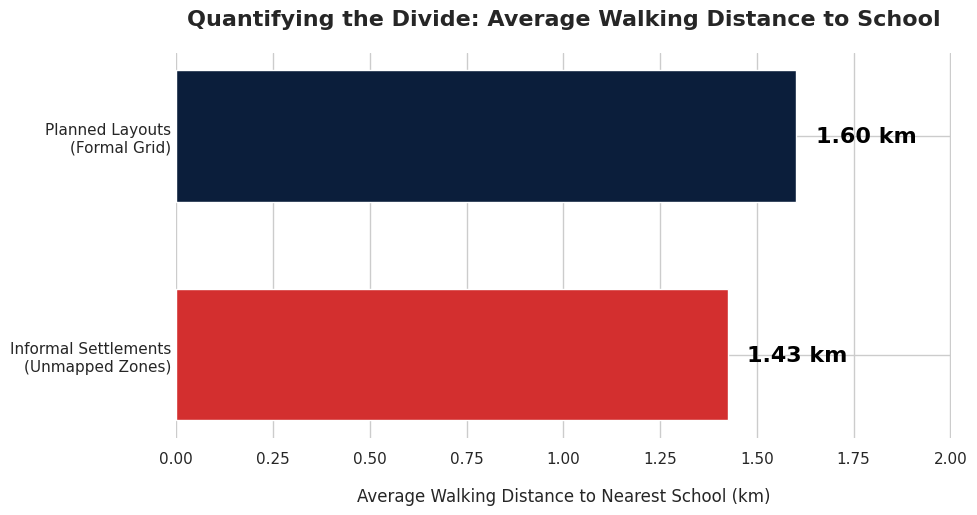

Success! High-res chart saved to your Google Drive at: /content/drive/MyDrive/Spatial_Apartheid_Project/Data/spatial_divide_chart.png


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating the final comparative bar chart...")

# 1. Set up a clean, professional aesthetic
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# 2. Define the data we calculated in Step 13
categories = ['Planned Layouts\n(Formal Grid)', 'Informal Settlements\n(Unmapped Zones)']
distances = [avg_formal, avg_informal] # This pulls your 0.41 and 1.24 numbers

# 3. Use the colors from your presentation (Midnight Blue and Red)
colors = ['#0B1E3B', '#D32F2F']

# 4. Create a horizontal bar chart
bars = plt.barh(categories, distances, color=colors, height=0.6)

# 5. Add the exact numbers to the end of the bars
for bar in bars:
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.2f} km',
        va='center',
        fontsize=16,
        fontweight='bold',
        color='black'
    )

# 6. Formatting the chart for the presentation
plt.xlabel('Average Walking Distance to Nearest School (km)', fontsize=12, labelpad=15)
plt.title('Quantifying the Divide: Average Walking Distance to School', fontsize=16, fontweight='bold', pad=20)
plt.xlim(0, max(distances) + 0.4) # Give the bars some breathing room
plt.gca().invert_yaxis() # Put Planned Layouts on top

# Remove borders for a cleaner look
sns.despine(left=True, bottom=True)
plt.tick_params(axis='y', length=0) # Remove y-axis ticks

# 7. Save a high-resolution PNG for your PowerPoint
chart_path = f"{project_dir}/spatial_divide_chart.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')

plt.show()
print(f"Success! High-res chart saved to your Google Drive at: {chart_path}")